# Степени матрицы смежности

Три вида умножения матрицы смежности ориентированного графа: обычное, булево и тропическое (min-plus). Для каждого своя единичная матрица и свой смысл степени $A^k$. Возведение в степень наивное и бинарное, пример — граф Петерсена со случайной ориентацией рёбер.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import time, random, math
from matplotlib.colors import LinearSegmentedColormap

INF = float('inf')

## Три вида умножения матриц

In [2]:
def mat_mul_std(A, B):
  """Обычное матричное умножение над целыми"""
  n = len(A)
  C = [[0]*n for _ in range(n)]
  for i in range(n):
    for k in range(n):
      if A[i][k] == 0:
        continue
      for j in range(n):
        C[i][j] += A[i][k] * B[k][j]
  return C

def mat_mul_bool(A, B):
  """Булево (бинарное) умножение"""
  n = len(A)
  C = [[0]*n for _ in range(n)]
  for i in range(n):
    for k in range(n):
      if not A[i][k]:
        continue
      for j in range(n):
        if B[k][j]:
          C[i][j] = 1
  return C

def mat_mul_trop(A, B):
  """Тропическое умножение"""
  n = len(A)
  C = [[INF]*n for _ in range(n)]
  for i in range(n):
    for k in range(n):
      if A[i][k] == INF:
        continue
      for j in range(n):
        if B[k][j] == INF:
          continue
        val = A[i][k] + B[k][j]
        if val < C[i][j]:
          C[i][j] = val
  return C

MUL = {
    'std': mat_mul_std,
    'bool': mat_mul_bool,
    'trop': mat_mul_trop,
}

## NumPy-оптимизированные версии

In [3]:
def mat_mul_std_np(A, B):
  return A @ B

def mat_mul_bool_np(A, B):
  return np.minimum(A.astype(np.int16) @ B.astype(np.int16), 1).astype(np.int8)

def mat_mul_trop_np(A, B):
  """Тропическое умножение через broadcasting: эффективнее для больших n"""
  # A[i,k] + B[k,j] по всем k -> берём min
  # broadcasting: (n,n,1) + (1,n,n) -> (n,n,n), min по оси 1
  return np.min(A[:, :, None] + B[None, :, :], axis=1)

MUL_NP = {
    'std':  mat_mul_std_np,
    'bool': mat_mul_bool_np,
    'trop': mat_mul_trop_np,
}

def identity_np(n, t):
  if t == 'trop':
      I = np.full((n, n), np.inf); np.fill_diagonal(I, 0.0)
  elif t == 'bool':
      I = np.eye(n, dtype=np.int8)
  else:
      I = np.eye(n, dtype=np.int64)
  return I

Проверка: списочные версии совпадают с NumPy на случайных матрицах.

In [4]:
rng_chk = np.random.default_rng(0)
for t in ['std', 'bool', 'trop']:
  for n_chk in [1, 5, 12]:
    X = (rng_chk.random((n_chk, n_chk)) < 0.4).astype(np.int64)
    Y = (rng_chk.random((n_chk, n_chk)) < 0.4).astype(np.int64)
    if t == 'trop':
      X = np.where(X > 0, rng_chk.integers(1, 9, X.shape), np.inf)
      Y = np.where(Y > 0, rng_chk.integers(1, 9, Y.shape), np.inf)
    ref = MUL_NP[t](X, Y)
    got = np.array(MUL[t](X.tolist(), Y.tolist()), dtype=float)
    assert np.array_equal(got, ref.astype(float)), (t, n_chk)
print("списочные и NumPy-версии совпадают")

списочные и NumPy-версии совпадают


## Быстрое и наивное возведение в степень

In [5]:
def mat_pow_fast(M, k, t):
  """
  Быстрое возведение в степень через бинарное разложение k
  Сложность: O(n^3 * log k) вместо O(n^3 * k)
  """
  mul = MUL_NP[t]
  n = len(M)
  result = identity_np(n, t)
  base = M.copy()
  ops = 0
  while k > 0:
      if k & 1:
          result = mul(result, base)
          ops += 1
      k >>= 1
      if k:
          base = mul(base, base)
          ops += 1
  return result, ops

def mat_pow_naive(M, k, t):
  """
  Наивное возведение в степень: k умножений подряд
  Сложность: O(n^3 * k)
  """
  mul = MUL_NP[t]
  result = identity_np(len(M), t)
  for _ in range(k):
      result = mul(result, M)
  return result, k

## Генераторы графов и визуализация

In [6]:
def petersen_random(seed=None):
  """Граф Петерсена со случайной ориентацией рёбер"""
  rng = random.Random(seed)
  G = nx.DiGraph()
  G.add_nodes_from(range(10))
  outer = list(range(5))
  inner = [5,7,9,6,8] # пентаграмма: 5-7-9-6-8-5
  for i in range(5):
      a,b = outer[i], outer[(i+1)%5]
      G.add_edge(a,b) if rng.random()<.5 else G.add_edge(b,a)
  for i in range(5):
      a,b = outer[i], 5+i
      G.add_edge(a,b) if rng.random()<.5 else G.add_edge(b,a)
  for i in range(5):
      a,b = inner[i], inner[(i+1)%5]
      G.add_edge(a,b) if rng.random()<.5 else G.add_edge(b,a)
  return G

def random_digraph(n, p=0.3, seed=None):
  rng = random.Random(seed)
  G = nx.DiGraph()
  G.add_nodes_from(range(n))
  for i in range(n):
      for j in range(n):
          if i != j and rng.random() < p:
              G.add_edge(i, j)
  return G

def adj_matrix(G):
  n = G.number_of_nodes()
  A = np.zeros((n, n), dtype=np.int64)
  for u, v in G.edges():
      A[u][v] = 1
  return A

def trop_matrix(A):
    """Матрица смежности -> тропическая (0 -> inf для несмежных)"""
    n = len(A)
    M = np.where(A > 0, A.astype(float), np.inf)
    np.fill_diagonal(M, 0.0)
    return M

Позиции вершин Петерсена

In [7]:
def petersen_pos():
  pos = {}
  for i in range(5):
      a = -math.pi/2 + 2*math.pi*i/5
      pos[i]   = ( math.cos(a),        math.sin(a))
      pos[5+i] = (0.45*math.cos(a), 0.45*math.sin(a))
  return pos

Единый стиль графиков

In [8]:
BLUE_CMAP = LinearSegmentedColormap.from_list('bl', ['#f0f9ff','#0369a1'])
GREEN_CMAP = LinearSegmentedColormap.from_list('gr', ['#f0fdf4','#15803d'])
ORANGE_CMAP = LinearSegmentedColormap.from_list('or', ['#fff7ed','#c2410c'])
CMAPS = {'std': BLUE_CMAP, 'bool': GREEN_CMAP, 'trop': ORANGE_CMAP}

def draw_graph(G, ax, title='', pos=None, node_color='#dbeafe', edge_color='#475569'):
  if pos is None: pos = nx.spring_layout(G, seed=1)
  nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_color,
                          node_size=500, edgecolors='#1d4ed8', linewidths=1.2)
  nx.draw_networkx_labels(G, pos, ax=ax, font_size=8,
                          font_color='#1e3a5f', font_weight='bold')
  nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_color,
                          arrows=True, arrowsize=12, width=1.1,
                          connectionstyle='arc3,rad=0.08')
  ax.set_title(title, fontsize=10, pad=6); ax.axis('off')



def draw_matrix(M_raw, ax, title='', cmap=BLUE_CMAP, vmax=None, fmt=None):
  """Тепловая карта с подписями. M_raw — numpy array или список списков"""
  M = np.array([[0 if v==np.inf else v for v in row] for row in M_raw], dtype=float)
  orig = np.array(M_raw, dtype=object)
  n = len(M)
  if vmax is None: vmax = M.max() if M.max() > 0 else 1
  ax.imshow(M, cmap=cmap, aspect='auto', vmin=0, vmax=vmax)
  fs = max(5, 9 - n//5)
  thresh = vmax * 0.55
  for i in range(n):
      for j in range(n):
          v = orig[i][j]
          txt = 'inf' if v == INF or v == np.inf else (fmt%v if fmt else str(int(v)))
          col = 'white' if float(M[i][j]) > thresh else '#1e293b'
          ax.text(j, i, txt, ha='center', va='center', fontsize=fs, color=col)
  ax.set_xticks(range(n)); ax.set_yticks(range(n))
  ax.set_xticklabels(range(n), fontsize=7)
  ax.set_yticklabels(range(n), fontsize=7)
  ax.set_title(title, fontsize=9, pad=5)


def draw_graph_from_matrix(M_bool, ax, title='', node_color='#dcfce7'):
  """Строит и рисует граф по булевой матрице (визуализация A^k как графа)"""
  n = len(M_bool)
  G = nx.DiGraph()
  G.add_nodes_from(range(n))
  for i in range(n):
      for j in range(n):
          if M_bool[i][j]: G.add_edge(i,j)
  pos = nx.circular_layout(G)
  draw_graph(G, ax, title=title, pos=pos,
             node_color=node_color, edge_color='#166534')

## Обычное умножение - маршруты в графе Петерсена

Какие степени интересны?

k = 1 - сама матрица смежности

k = 2 - пути через одну промежуточную вершину

A^6[i][j] = число маршрутов длины ровно 6 из i в j

k = n - все маршруты длины n (след(A^k) = число замкнутых маршрутов длины k)

k = 2n - элементы очень большие

Сильносвязный граф при seed = 5, для несильносвязного seed = 42

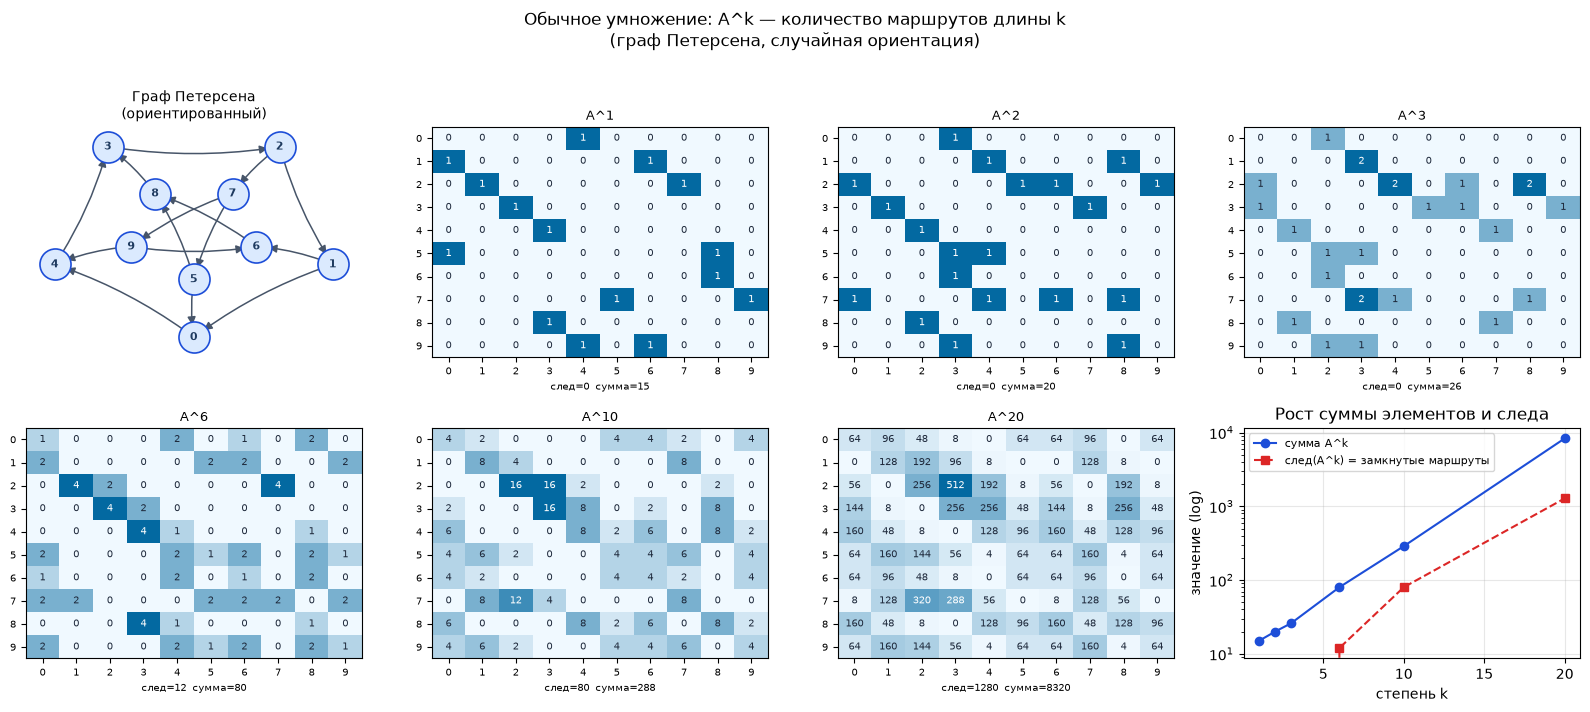

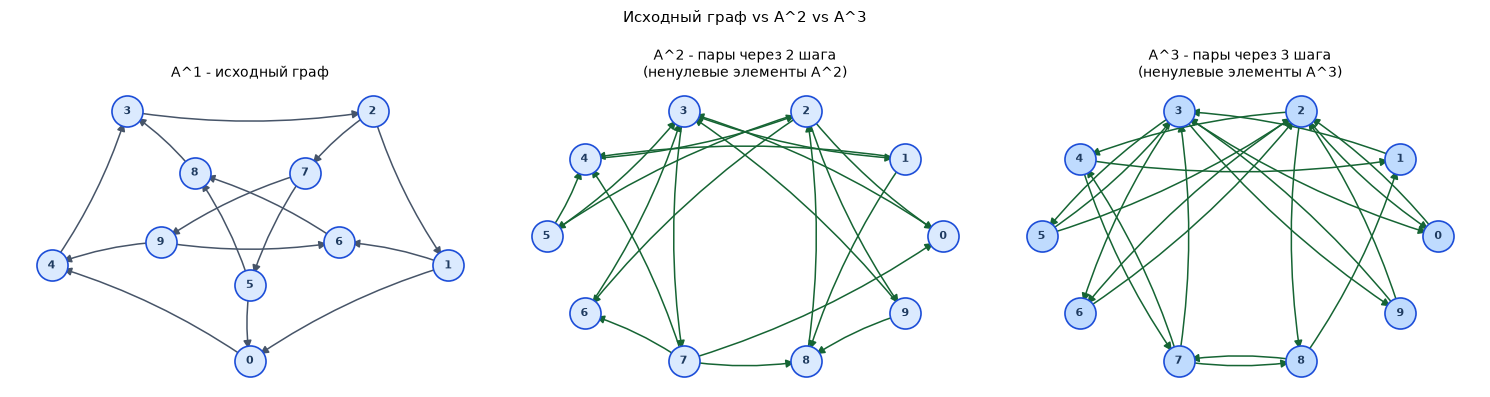


ИНТЕРПРЕТАЦИЯ:

  k =  1:  сумма = 15  след =  0  ненулевых = 15/100
        -> матрица смежности; A[i][j]=1 <-> ребро i->j

  k =  2:  сумма = 20  след =  0  ненулевых = 20/100
        -> A^2[i][j] = число путей i->x->j через 1 промежуточную вершину

  k =  3:  сумма = 26  след =  0  ненулевых = 22/100
        -> при k=3 появляются маршруты длины 3, ненулевых=22/100

  k = 10:  сумма = 288  след = 80  ненулевых = 54/100
        -> при k=10 след=80: это число замкнутых маршрутов длины 10


In [9]:
random.seed(5)
Gp = petersen_random(seed=5)
A = adj_matrix(Gp)
n = 10
pos_p = petersen_pos()

# Степени: 1, 2, 3, 6, 10 (=n), 20 (=2n)
k_std = [1, 2, 3, 6, 10, 20]
powers_std = {}
for k in k_std:
  Ak, _ = mat_pow_fast(A.copy(), k, 'std')
  powers_std[k] = Ak

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Обычное умножение: A^k — количество маршрутов длины k\n"
             "(граф Петерсена, случайная ориентация)", fontsize=12, y=1.01)

# Рисуем граф
draw_graph(Gp, axes[0][0], title="Граф Петерсена\n(ориентированный)", pos=pos_p)

# Матрица A^1 и тепловые карты
shown_k = [1, 2, 3, 6, 10, 20]
flat_axes = [axes[0][1], axes[0][2], axes[0][3],
             axes[1][0], axes[1][1], axes[1][2]]
for ax, k in zip(flat_axes, shown_k):
  Ak = powers_std[k]
  draw_matrix(Ak, ax, title=f"A^{k}", cmap=BLUE_CMAP)
  trace = int(np.trace(Ak))
  total = int(Ak.sum())
  ax.set_xlabel(f"след={trace}  сумма={total}", fontsize=7)

# График: рост суммы элементов и следа
ax_grow = axes[1][3]
sums = [int(powers_std[k].sum())  for k in k_std]
traces = [int(np.trace(powers_std[k])) for k in k_std]
ax_grow.plot(k_std, sums, 'o-', color='#1d4ed8', label='сумма A^k')
ax_grow.plot(k_std, traces, 's--', color='#dc2626', label='след(A^k) = замкнутые маршруты')
ax_grow.set_yscale('log')
ax_grow.set_xlabel('степень k'); ax_grow.set_ylabel('значение (log)')
ax_grow.set_title('Рост суммы элементов и следа')
ax_grow.legend(fontsize=8); ax_grow.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Граф A^2 и A^3 - квадрат и куб графа
fig, axes_sq = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Исходный граф vs A^2 vs A^3", fontsize=11)

draw_graph(Gp, axes_sq[0], title="A^1 - исходный граф", pos=pos_p)

A2_bool = (powers_std[2] > 0).astype(int)
draw_graph_from_matrix(A2_bool, axes_sq[1],
    title="A^2 - пары через 2 шага\n(ненулевые элементы A^2)",
    node_color='#dbeafe')

A3_bool = (powers_std[3] > 0).astype(int)
draw_graph_from_matrix(A3_bool, axes_sq[2],
    title="A^3 - пары через 3 шага\n(ненулевые элементы A^3)",
    node_color='#bfdbfe')

plt.tight_layout()
plt.show()

print("\nИНТЕРПРЕТАЦИЯ:")
for k in [1, 2, 3, 10]:
  Ak = powers_std[k]
  trace = int(np.trace(Ak))
  total = int(Ak.sum())
  nonzero = int((Ak > 0).sum())
  print(f"\n  k = {k:2d}:  сумма = {total:2d}  след = {trace:2d}  ненулевых = {nonzero}/100")
  if k == 1:
      print("        -> матрица смежности; A[i][j]=1 <-> ребро i->j")
  elif k == 2:
      print(f"        -> A^2[i][j] = число путей i->x->j через 1 промежуточную вершину")
  elif k == 3:
      print(f"        -> при k=3 появляются маршруты длины 3, ненулевых={nonzero}/100")
  elif k == 10:
    print(f"        -> при k=10 след={trace}: это число замкнутых маршрутов длины 10")

## Булево умножение - достижимость, диаметр, транзит. замыкание

Какие степени интересны?

k = 1 - исходная ориентация

k = 2,3,... - наблюдаем, когда матрица заполнится -> диаметр графа

k = d - при k = диаметр накопленный OR впервые становится матрицей из единиц

k = n - 1 = 9 - последняя нужная степень: накопленный OR A^1v...vA^9 = транзитивное замыкание

Если граф сильносвязный, накопленный OR A^1v...vA^(n-1) = матрица из единиц

Дополнительно: накопленный OR по k=1..n-1 даёт матрицу достижимости


  Диаметр графа = 6
  Транзитивное замыкание (накопл. OR): ненулевых = 100/100
  Сильная связность: ДА (все 90 внедиагональных = 1)


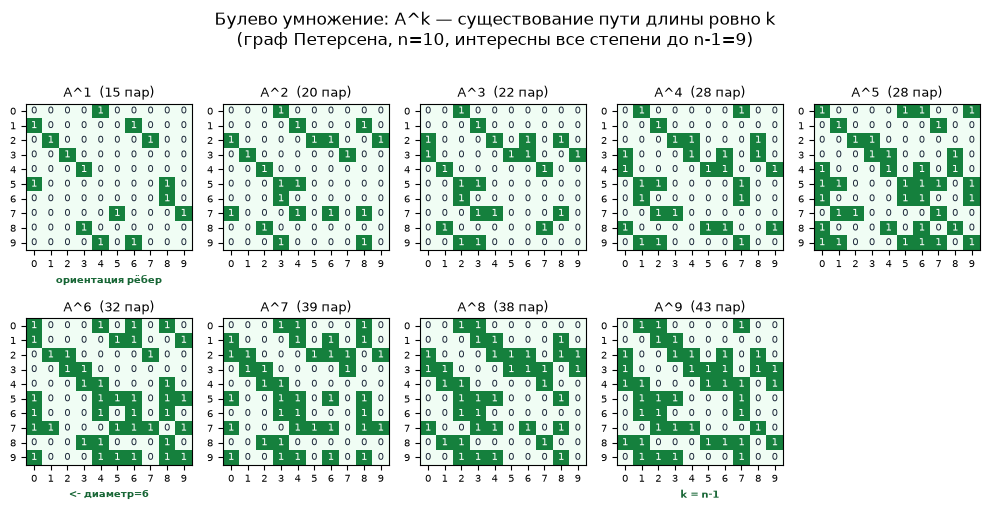

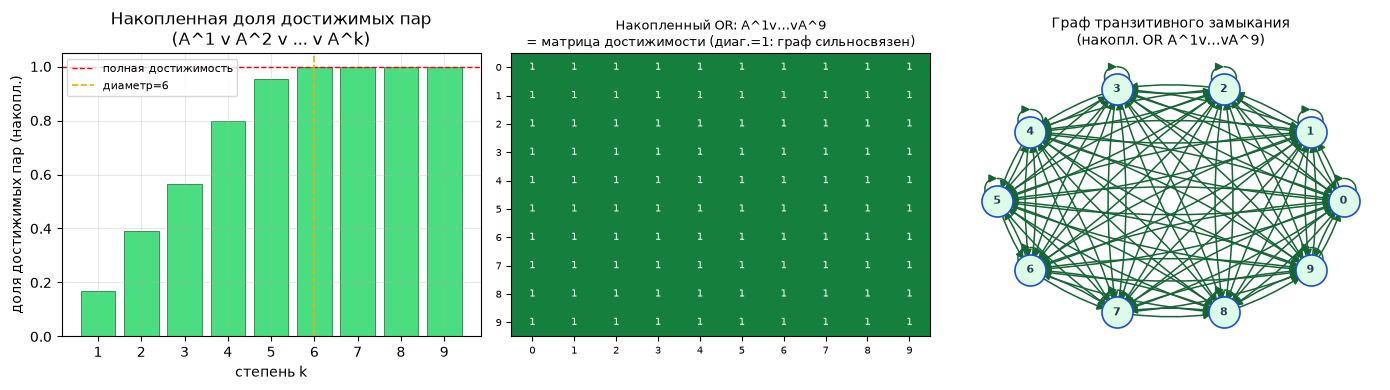

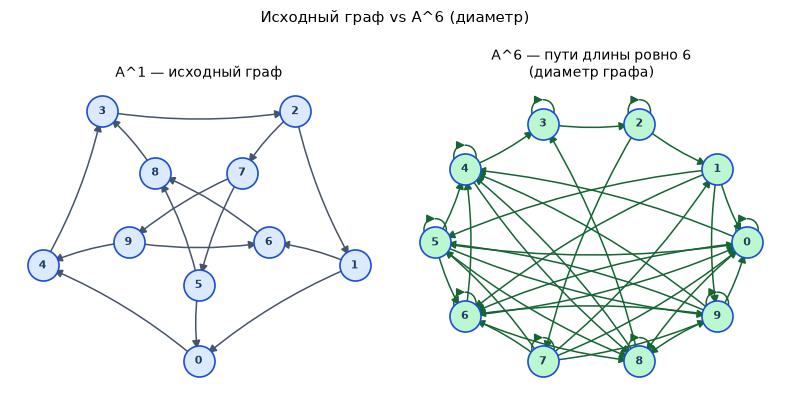


ИНТЕРПРЕТАЦИЯ:
   Диаметр ориент. Петерсена = 6
   При другой ориентации Петерсен может быть не сильносвязен
   Любые две вершины достижимы маршрутом длины <= 6
   A^k при k<6 содержит нули
   При k=6 накопленный OR впервые = матрица из единиц
   A^1 v ... v A^9 = транзитивное замыкание (достижимость за любое число шагов)
   Сильная связность: граф сильносвязен


In [10]:
Ab = A.astype(np.int8)
n = 10

# Считаем A^k для k=1..9 и накопленный OR
powers_bool = {}
cumulative = np.zeros((n,n), dtype=np.int8)
fill_at_k = {}   # k -> доля единиц в A^k (без диагонали)

for k in range(1, n):
  Ak, _ = mat_pow_fast(Ab, k, 'bool')
  powers_bool[k] = Ak
  cumulative = np.minimum(cumulative + Ak, 1).astype(np.int8)
  # доля достижимых пар (без диагонали)
  off = Ak.copy(); np.fill_diagonal(off, 0)
  fill_at_k[k] = off.sum() / (n*(n-1))

# Найти диаметр (наименьшее k, при котором cumulative без диагонали = 1)
diameter = None
cum_check = np.zeros((n,n), dtype=np.int8)
for k in range(1, n):
  cum_check = np.minimum(cum_check + powers_bool[k], 1).astype(np.int8)
  off = cum_check.copy()
  np.fill_diagonal(off, 0)
  if off.sum() == n*(n-1) and diameter is None:
      diameter = k

print(f"\n  Диаметр графа = {diameter if diameter else 'inf (граф не сильносвязен)'}")
print(f"  Транзитивное замыкание (накопл. OR): ненулевых = {(cumulative>0).sum()}/100")
is_sc = (cumulative.sum() - np.trace(cumulative)) == n*(n-1)
print(f"  Сильная связность: {'ДА' if is_sc else 'НЕТ'} "
      f"({'все' if is_sc else 'не все'} {n*(n-1)} внедиагональных = 1)")

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
fig.suptitle("Булево умножение: A^k — существование пути длины ровно k\n"
             "(граф Петерсена, n=10, интересны все степени до n-1=9)", fontsize=12, y=1.01)

for idx, k in enumerate(range(1, 10)):
  row, col = divmod(idx, 5)
  ax = axes[row][col]
  Ak = powers_bool[k]
  draw_matrix(Ak, ax, title=f"A^{k}  ({int((Ak>0).sum()-np.trace(Ak))} пар)",
              cmap=GREEN_CMAP, vmax=1)
  label = ""
  if k == 1: label = "ориентация рёбер"
  if k == diameter: label = f"<- диаметр={k}"
  if k == n-1:label = "k = n-1"
  if label: ax.set_xlabel(label, fontsize=7, color='#166534', fontweight='bold')
axes[1][4].axis('off')
plt.tight_layout()
plt.show()

# Дополнительно: как быстро заполняется матрица?
fig, axes2 = plt.subplots(1, 3, figsize=(14, 4))


# График заполнения — накопленный OR
cumulative_fill = {}
cum_tmp = np.zeros((n, n), dtype=np.int8)
for k in range(1, n):
    cum_tmp = np.minimum(cum_tmp + powers_bool[k], 1).astype(np.int8)
    off = cum_tmp.copy(); np.fill_diagonal(off, 0)
    cumulative_fill[k] = off.sum() / (n*(n-1))

axes2[0].bar(list(cumulative_fill.keys()), list(cumulative_fill.values()),
             color='#4ade80', edgecolor='#166534', linewidth=0.5)
axes2[0].axhline(1.0, color='red', ls='--', lw=1, label='полная достижимость')
if diameter:
    axes2[0].axvline(diameter, color='orange', ls='--', lw=1.2,
                     label=f'диаметр={diameter}')
axes2[0].set_xlabel('степень k')
axes2[0].set_ylabel('доля достижимых пар (накопл.)')
axes2[0].set_title('Накопленная доля достижимых пар\n(A^1 v A^2 v ... v A^k)')
axes2[0].legend(fontsize=8); axes2[0].grid(alpha=0.3)
axes2[0].set_xticks(range(1, n))

# Накопленный OR матрица достижимости
diag_note = "(диаг.=1: граф сильносвязен)" if is_sc else "(диаг. не всегда 1)"
draw_matrix(cumulative, axes2[1],
            title=f"Накопленный OR: A^1v…vA^{n-1}\n= матрица достижимости {diag_note}",
            cmap=GREEN_CMAP, vmax=1)

# Граф, построенный по транзитивному замыканию
draw_graph_from_matrix(cumulative, axes2[2], title="Граф транзитивного замыкания\n(накопл. OR A^1v…vA^9)")

plt.tight_layout()
plt.show()
if diameter != None:
  # Граф A^diameter - пары с путём длины ровно diameter
  fig, axes_d = plt.subplots(1, 2, figsize=(8, 4))
  fig.suptitle(f"Исходный граф vs A^{diameter} (диаметр)", fontsize=11)
  draw_graph(Gp, axes_d[0], title="A^1 — исходный граф", pos=pos_p)
  draw_graph_from_matrix(powers_bool[diameter], axes_d[1],
      title=f"A^{diameter} — пути длины ровно {diameter}\n(диаметр графа)",
      node_color='#bbf7d0')
  plt.tight_layout()
  plt.show()

print("\nИНТЕРПРЕТАЦИЯ:")
if diameter:
    print(f"   Диаметр ориент. Петерсена = {diameter}")
    print("   При другой ориентации Петерсен может быть не сильносвязен")
    print(f"   Любые две вершины достижимы маршрутом длины <= {diameter}")
    print(f"   A^k при k<{diameter} содержит нули")
    print(f"   При k={diameter} накопленный OR впервые = матрица из единиц")
else:
    print("   Граф не сильносвязен: диаметр = INF")
    print("   Некоторые пары недостижимы ни за какое число шагов")
    print("   При другой ориентации Петерсен может быть сильносвязен")
print(f"   A^1 v ... v A^{n-1} = транзитивное замыкание (достижимость за любое число шагов)")
sc_str = "граф сильносвязен" if is_sc else "граф не сильносвязен"
print(f"   Сильная связность: {sc_str}")

### Проверка: алгоритм Уоршелла

Транзитивное замыкание другим способом — тройным циклом по промежуточной вершине.

In [11]:
TC = Ab.copy()
for k in range(n): # промежуточная вершина
  for i in range(n):
    for j in range(n):
      TC[i][j] = TC[i][j] or (TC[i][k] and TC[k][j])

print("Уоршелл совпадает с накопленным OR:", np.array_equal(TC, cumulative))

Уоршелл совпадает с накопленным OR: True


### Все ориентации графа Петерсена

У графа Петерсена 15 рёбер, ориентаций $2^{15} = 32768$. Перебор всех: сколько из них сильносвязны и какой у них диаметр.

In [12]:
outer = list(range(5)); inner = [5,7,9,6,8]
pet_edges = ([(outer[i], outer[(i+1)%5]) for i in range(5)]
           + [(outer[i], 5+i) for i in range(5)]
           + [(inner[i], inner[(i+1)%5]) for i in range(5)])

diam_count = {}
for mask in range(1 << 15):
  G_o = nx.DiGraph()
  G_o.add_nodes_from(range(10))
  for b, (u, v) in enumerate(pet_edges):
    G_o.add_edge(u, v) if mask >> b & 1 else G_o.add_edge(v, u)
  if nx.is_strongly_connected(G_o):
    d = nx.diameter(G_o)
    diam_count[d] = diam_count.get(d, 0) + 1

total_sc = sum(diam_count.values())
print(f"Сильносвязных ориентаций: {total_sc} из {1 << 15} ({total_sc / (1 << 15):.1%})")
for d in sorted(diam_count):
  print(f"  диаметр {d}: {diam_count[d]:4d}")

Сильносвязных ориентаций: 1920 из 32768 (5.9%)
  диаметр 6:  480
  диаметр 7:  720
  диаметр 8:  480
  диаметр 9:  240


## Тропическое умножение - кратчайшие пути

Какие степени интересны?

k = 1 - длины ребер (0 или 1 для невзвешенного)

k = 2,3,... - кратчайший путь из i в j, использующий не более k рёбер

k = n-1 = 9 - кратчайшие пути, использующие <= n-1 ребер (аналог алгоритма Беллмана-Форда)

D[i][j] = min(A^1[i][j], ..., A^(n-1)[i][j]) = A^(n-1)[i][j] —
накопленный min совпадает с последней степенью именно из-за нуля на диагонали.


  Верификация (vs NetworkX): все расстояния совпадают
  Накопленный min совпадает с A^9: True
  Конечных элементов в матрице расстояний: 100/100
  Максимальное кратчайшее расстояние (диаметр): 6


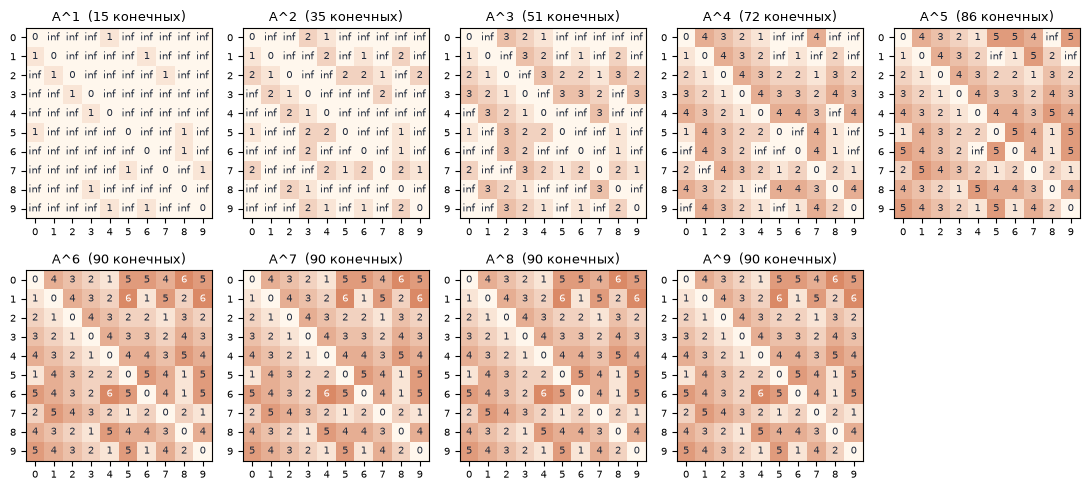

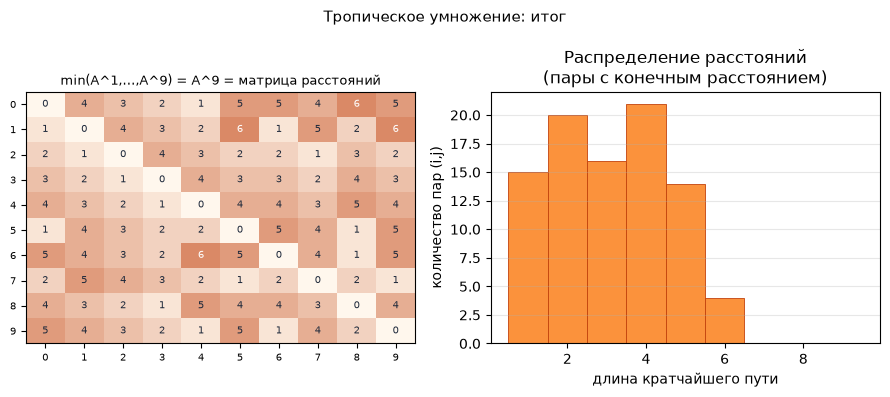

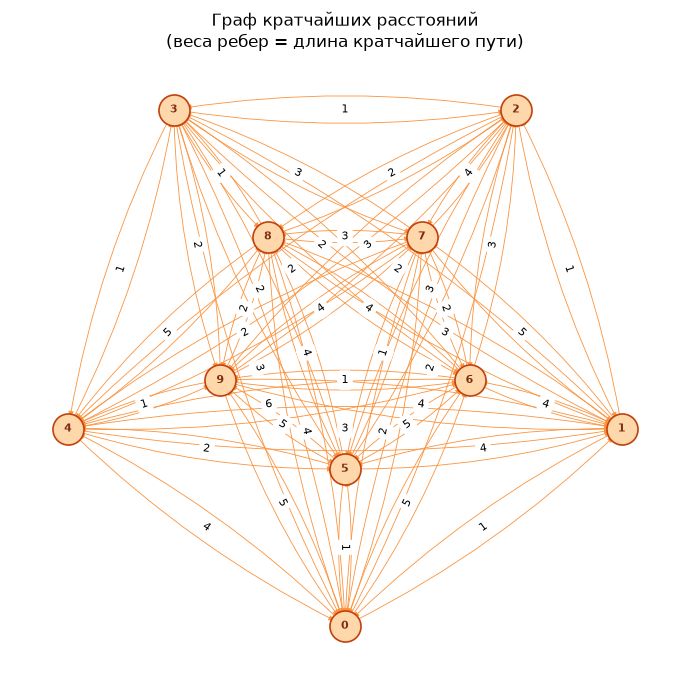


ИНТЕРПРЕТАЦИЯ:
   A^k[i][j] - длина кратчайшего пути, использующего не более k рёбер
   Если A^k[i][j]=inf - пути из не более чем k рёбер не существует
   Накопленный min по A^1..A^9 = матрица всех кратчайших расстояний
   Это тропический аналог алгоритма Флойда–Уоршелла
   Результат верифицирован через NetworkX: совпадает


In [13]:
Mt = trop_matrix(A)
n  = 10

# Степени k=1..n-1, накопленный min
powers_trop = {}
dist = np.full((n,n), np.inf)
np.fill_diagonal(dist, 0)

for k in range(1, n):
  Ak, _ = mat_pow_fast(Mt, k, 'trop')
  powers_trop[k] = Ak
  dist = np.minimum(dist, Ak)

# Верификация через NetworkX
dist_nx = dict(nx.all_pairs_shortest_path_length(Gp))
errors = 0
for i in range(n):
  for j in range(n):
      if i == j: continue
      our = dist[i][j]
      ref = dist_nx.get(i,{}).get(j, np.inf)
      if our != ref: errors += 1

print(f"\n  Верификация (vs NetworkX): {'все расстояния совпадают' if errors==0 else f'ошибок: {errors}'}")
print(f"  Накопленный min совпадает с A^{n-1}: {np.array_equal(dist, powers_trop[n-1])}")
print(f"  Конечных элементов в матрице расстояний: {np.isfinite(dist).sum()}/100")
print(f"  Максимальное кратчайшее расстояние (диаметр): "
      f"{int(dist[np.isfinite(dist)].max())}")

# Рисуем
fig, axes = plt.subplots(2, 5, figsize=(11, 5))


for idx, k in enumerate(range(1, 10)):
  row, col = divmod(idx, 5)
  ax = axes[row][col]
  Ak = powers_trop[k]
  Ak_disp = [[INF if v==np.inf else int(v) for v in row] for row in Ak.tolist()]
  fin = np.isfinite(Ak).sum() - n   # конечных, кроме диагонали
  draw_matrix(Ak_disp, ax, title=f"A^{k}  ({fin} конечных)", cmap=ORANGE_CMAP, vmax=n)
axes[1][4].axis('off')
plt.tight_layout()
plt.show()

# Итоговая матрица расстояний и гистограмма
fig, axes3 = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle("Тропическое умножение: итог", fontsize=11)

dist_disp = [[INF if v==np.inf else int(v) for v in row] for row in dist.tolist()]
draw_matrix(dist_disp, axes3[0],
            title="min(A^1,…,A^9) = A^9 = матрица расстояний",
            cmap=ORANGE_CMAP, vmax=n)

# Гистограмма кратчайших расстояний
finite_dists = [dist[i][j] for i in range(n) for j in range(n)
                if i!=j and np.isfinite(dist[i][j])]
axes3[1].hist(finite_dists, bins=range(1, n+1), color='#fb923c',
              edgecolor='#c2410c', linewidth=0.6, align='left')
axes3[1].set_xlabel('длина кратчайшего пути')
axes3[1].set_ylabel('количество пар (i,j)')
axes3[1].set_title('Распределение расстояний\n(пары с конечным расстоянием)')
axes3[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# Взвешенный граф кратчайших расстояний
fig, ax_dist = plt.subplots(figsize=(7, 7))
G_dist = nx.DiGraph()
G_dist.add_nodes_from(range(n))
for i in range(n):
    for j in range(n):
        if i != j and np.isfinite(dist[i][j]):
            G_dist.add_edge(i, j, weight=int(dist[i][j]))
pos_dist = petersen_pos()
nx.draw_networkx_nodes(G_dist, pos_dist, ax=ax_dist,
    node_color='#fed7aa', node_size=500,
    edgecolors='#c2410c', linewidths=1.2)
nx.draw_networkx_labels(G_dist, pos_dist, ax=ax_dist,
    font_size=8, font_color='#7c2d12', font_weight='bold')
nx.draw_networkx_edges(G_dist, pos_dist, ax=ax_dist,
    edge_color='#fb923c', arrows=True, arrowsize=8,
    width=0.6, connectionstyle='arc3,rad=0.08')
edge_labels = {(i,j): int(dist[i][j])
               for i,j in G_dist.edges() if np.isfinite(dist[i][j])}
ax_dist.set_title('Граф кратчайших расстояний\n(веса ребер = длина кратчайшего пути)')
nx.draw_networkx_edge_labels(G_dist, pos_dist, edge_labels,
    font_size=8, ax=ax_dist)


ax_dist.axis('off')
plt.tight_layout()
plt.show()

print("\nИНТЕРПРЕТАЦИЯ:")
print("   A^k[i][j] - длина кратчайшего пути, использующего не более k рёбер")
print("   Если A^k[i][j]=inf - пути из не более чем k рёбер не существует")
print(f"   Накопленный min по A^1..A^{n-1} = матрица всех кратчайших расстояний")
print("   Это тропический аналог алгоритма Флойда–Уоршелла")
print(f"   Результат верифицирован через NetworkX: {'совпадает' if errors==0 else 'расхождение'}")

## Сравнение: быстрое vs наивное - теория и замеры

Наивное возведение — k умножений. Быстрое — $\lfloor \log_2 k \rfloor$ возведений в квадрат и по одному умножению на каждую единицу в двоичной записи k. Худший случай, когда все биты равны единице: $2\lfloor \log_2 k \rfloor + 1$.

       k    наивн.    быстр.     теор. ускорение
       4         4         3                 1.3x
       8         8         4                 2.0x
      15        15         7                 2.1x
      16        16         5                 3.2x
      63        63        11                 5.7x
      64        64         7                 9.1x
     128       128         8                16.0x
     255       255        15                17.0x
     256       256         9                28.4x

      n     тип    быстр.(мс)    наивн.(мс)   умн.быстр   ускорение
  ------------------------------------------------------------
     10    bool          0.02          0.09           7         5.0x
     10    trop          0.32          0.24           7         0.8x
     10     std          0.02          0.05           7         2.8x
     50    bool          0.29          2.31           7         8.1x
     50    trop          0.65          5.69           7         8.7x
     50     std         

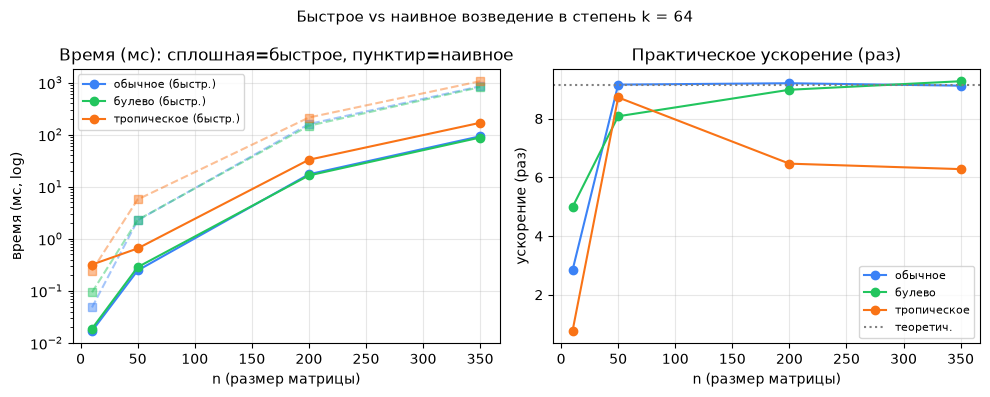


ИНТЕРПРЕТАЦИЯ:
   При k=64: 7 умножений вместо 64, теоретическое ускорение 9.1x
   Количество умножений не зависит от n - только от k
   Выигрыш растёт с k: при k=256 это 9 умножений вместо 256
   При k=255 (все биты единицы) - 15 умножений


In [14]:
def fast_ops(k):
  return k.bit_length() - 1 + bin(k).count('1')

print(f"  {'k':>6}  {'наивн.':>8}  {'быстр.':>8}  {'теор. ускорение':>18}")
for k in [4, 8, 15, 16, 63, 64, 128, 255, 256]:
    assert mat_pow_fast(np.eye(2, dtype=np.int64), k, 'std')[1] == fast_ops(k)
    print(f"  {k:>6}  {k:>8}  {fast_ops(k):>8}  {k/fast_ops(k):>18.1f}x")

print()

# Практические замеры
configs = [(10,'bool'), (10,'trop'), (10,'std'),
           (50,'bool'), (50,'trop'), (50,'std'),
           (200,'bool'), (200,'trop'), (200, 'std'),
           (350,'bool'), (350,'trop'), (350, 'std')]

k_exp = 64
print(f"  {'n':>5}  {'тип':>6}  {'быстр.(мс)':>12}  {'наивн.(мс)':>12}  "
      f"{'умн.быстр':>10}  {'ускорение':>10}")
print("  " + "-"*60)

bench_results = []
for n_b, mul_type in configs:
  G_b = random_digraph(n_b, p=0.3, seed=5)
  A_b = adj_matrix(G_b)
  M_b = trop_matrix(A_b) if mul_type=='trop' else A_b.astype(
        np.int8 if mul_type=='bool' else np.int64)

  t0 = time.perf_counter()
  _, ops_f = mat_pow_fast(M_b.copy(), k_exp, mul_type)
  t_f = time.perf_counter() - t0

  t0 = time.perf_counter()
  _, ops_n = mat_pow_naive(M_b.copy(), k_exp, mul_type)
  t_n = time.perf_counter() - t0

  sp = t_n / t_f if t_f > 1e-9 else 0
  bench_results.append((n_b, mul_type, t_f*1000, t_n*1000, ops_f, ops_n, sp))
  print(f"  {n_b:>5}  {mul_type:>6}  {t_f*1000:>12.2f}  {t_n*1000:>12.2f}  "
        f"{ops_f:>10}  {sp:>10.1f}x")

# Визуализация замеров
types = ['std', 'bool', 'trop']
type_labels = {'std':'обычное', 'bool':'булево', 'trop':'тропическое'}
type_colors = {'std':'#3b82f6', 'bool':'#22c55e', 'trop':'#f97316'}

fig, axes4 = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(f"Быстрое vs наивное возведение в степень k = {k_exp}", fontsize=11)

for ax_idx, (ax_cur, mode) in enumerate(zip(axes4, ['time', 'speedup'])):
  for mul_type in types:
      rows = [(r[0], r[2], r[3], r[6]) for r in bench_results if r[1]==mul_type]
      if not rows: continue
      ns_  = [r[0] for r in rows]
      if mode == 'time':
          ax_cur.plot(ns_, [r[1] for r in rows], 'o-',
                      color=type_colors[mul_type], label=f'{type_labels[mul_type]} (быстр.)')
          ax_cur.plot(ns_, [r[2] for r in rows], 's--',
                      color=type_colors[mul_type], alpha=0.45)
      else:
          ax_cur.plot(ns_, [r[3] for r in rows], 'o-',
                      color=type_colors[mul_type], label=type_labels[mul_type])

  if mode == 'time':
      ax_cur.set_yscale('log')
      ax_cur.set_title('Время (мс): сплошная=быстрое, пунктир=наивное')
      ax_cur.set_ylabel('время (мс, log)')
  else:
      ax_cur.set_title('Практическое ускорение (раз)')
      ax_cur.set_ylabel('ускорение (раз)')
      ax_cur.axhline(k_exp / fast_ops(k_exp),
                       ls=':', color='gray', label='теоретич.')
  ax_cur.set_xlabel('n (размер матрицы)')
  ax_cur.legend(fontsize=8); ax_cur.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nИНТЕРПРЕТАЦИЯ:")
print(f"   При k={k_exp}: {fast_ops(k_exp)} умножений вместо {k_exp}, "
      f"теоретическое ускорение {k_exp/fast_ops(k_exp):.1f}x")
print("   Количество умножений не зависит от n - только от k")
print(f"   Выигрыш растёт с k: при k=256 это {fast_ops(256)} умножений вместо 256")
print(f"   При k=255 (все биты единицы) - {fast_ops(255)} умножений")

## Большие графы: n = 100, 300, 500


  k=16, булево умножение

       n     рёбер   время(мс)    умнож.    пар в A^k, %
  ----------------------------------------------------
     100       196         1.7         5           63.1%
     300       713        40.1         5           77.1%
     500      1253       182.8         5           84.3%


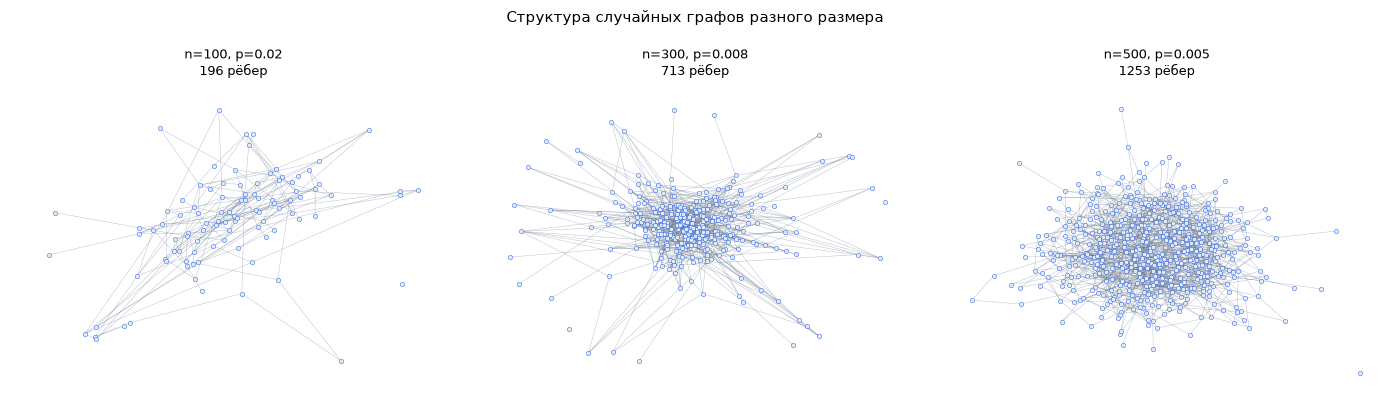


ИНТЕРПРЕТАЦИЯ:
   Булево возведение в степень k=16 на больших графах: A^16[i][j] = 1 <-> есть маршрут длины ровно 16
   Доля пар растёт с n: средняя степень n*p = 2.0, 2.4, 2.5
   Количество умножений одинаково при любом n
   Время растёт с увеличением n из-за роста размера матриц


In [15]:
large_configs = [(100, 0.02), (300, 0.008), (500, 0.005)]
k_large = 16

print(f"\n  k={k_large}, булево умножение\n")
print(f"  {'n':>6}  {'рёбер':>8}  {'время(мс)':>10}  "
      f"{'умнож.':>8}  {'пар в A^k, %':>14}")
print("  " + "-"*52)

for n_l, p_l in large_configs:
  G_l = random_digraph(n_l, p=p_l, seed=99)
  A_l = adj_matrix(G_l).astype(np.int8)
  t0  = time.perf_counter()
  Ak_l, ops_l = mat_pow_fast(A_l, k_large, 'bool')
  t_l = (time.perf_counter() - t0) * 1000
  reach = (Ak_l.sum() - np.trace(Ak_l)) / (n_l*(n_l-1)) * 100
  print(f"  {n_l:>6}  {G_l.number_of_edges():>8}  {t_l:>10.1f}  "
        f"{ops_l:>8}  {reach:>13.1f}%")

# Визуализация структуры больших графов
fig, axes_big = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Структура случайных графов разного размера", fontsize=11)
for ax_b, (n_l, p_l) in zip(axes_big, large_configs):
    G_l = random_digraph(n_l, p=p_l, seed=99)
    pos_l = nx.spring_layout(G_l, seed=42)
    nx.draw_networkx_nodes(G_l, pos_l, ax=ax_b,
        node_color='#dbeafe', node_size=10,
        edgecolors='#1d4ed8', linewidths=0.3)
    nx.draw_networkx_edges(G_l, pos_l, ax=ax_b,
        edge_color='#64748b', arrows=False, width=0.3, alpha=0.5)
    ax_b.set_title(f"n={n_l}, p={p_l}\n{G_l.number_of_edges()} рёбер", fontsize=9)
    ax_b.axis('off')
plt.tight_layout()
plt.show()

print("\nИНТЕРПРЕТАЦИЯ:")
print(f"   Булево возведение в степень k={k_large} на больших графах: A^{k_large}[i][j] = 1 <-> есть маршрут длины ровно {k_large}")
print("   Доля пар растёт с n: средняя степень n*p = " + ", ".join(f"{n_l*p_l:.1f}" for n_l, p_l in large_configs))
print("   Количество умножений одинаково при любом n")
print("   Время растёт с увеличением n из-за роста размера матриц")

## Выводы

1. Обычное умножение: $A^k[i][j]$ — число маршрутов длины k из i в j, $\operatorname{tr} A^k$ — число замкнутых маршрутов длины k. Элементы растут экспоненциально: у ориентированного графа Петерсена сумма элементов $A^{20}$ равна 8320, след 1280.

2. Булево умножение: $A^k[i][j] = 1$ тогда и только тогда, когда есть маршрут длины ровно k. Накопленный OR $A^1 \vee \dots \vee A^{n-1}$ — транзитивное замыкание, совпадает с результатом алгоритма Уоршелла. Диаметр — наименьшее k, при котором накопленный OR заполняется единицами целиком; при seed=5 это 6.

3. Тропическое умножение: $A^k[i][j]$ — длина кратчайшего пути, использующего не более k рёбер. Из-за нулей на диагонали накопленный минимум совпадает с $A^{n-1}$, матрица расстояний совпадает с NetworkX.

4. Быстрое возведение в степень: $\lfloor \log_2 k \rfloor$ возведений в квадрат плюс по умножению на каждую единицу в двоичной записи k. Для k = 64 это 7 умножений вместо 64; при n = 200 и 350 обычное и булево умножение ускоряются в 9,0–9,3 раза, тропическое в 6,3–6,5 раза.

5. Граф Петерсена: из $2^{15} = 32768$ ориентаций сильносвязны 1920. Диаметр 6 у 480 из них, 7 у 720, 8 у 480, 9 у 240, так что ориентация с seed=5 — одна из ориентаций с минимальным диаметром.